# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch1 2026-2027 — Major Project

**Problem Statement:** Agricultural performance is influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. This notebook analyzes a multi-season farm-level dataset to uncover meaningful seasonal patterns, relationships, and differences in agricultural performance, and to develop evidence-based conclusions and recommendations.

**Analytical Questions investigated in this notebook:**
1. How does crop yield vary across seasons (Kharif, Rabi, Zaid), and is the difference statistically significant?
2. How does economic performance (cost, revenue, profit) vary across seasons?
3. How does irrigation method efficiency change across seasons?
4. What environmental factors actually relate to yield, and how do they shift across seasons?
5. How does disease/pest risk vary across seasons, and does it affect outcomes?
6. Which states/regions perform best across seasons?


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', None)


## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_excel("seasonal_agriculture_performance_dataset.xlsx")
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


**Observations:**
- 4,000 farm-level records across 28 columns.
- Data spans 3 seasons (Kharif, Rabi, Zaid), 8 states, 10 districts, 8 crops, and 4 irrigation methods.
- `Yield_Tonnes_Ha` shows a huge gap between the 75th percentile (~2.8) and the max (~101) — a strong sign of outliers that need treatment before analysis.


## 3. Data Cleaning

### 3.1 Missing Values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)
print("\nPercentage missing:")
print((missing / len(df) * 100).round(2))


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Percentage missing:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


In [6]:
# Rainfall and Soil Moisture are environmental readings that vary meaningfully by season,
# so a season-wise median is a more faithful fill than a single global median.
for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    df[col] = df.groupby("Season")[col].transform(lambda s: s.fillna(s.median()))

# Yield is the core outcome variable — impute using the Crop + Season median,
# since expected yield depends heavily on which crop is grown in which season.
df["Yield_Tonnes_Ha"] = df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"].transform(
    lambda s: s.fillna(s.median())
)

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


### 3.2 Duplicate Records

In [7]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


### 3.3 Outlier Treatment — Yield_Tonnes_Ha

IQR upper bound: 5.52  |  Records above bound: 304


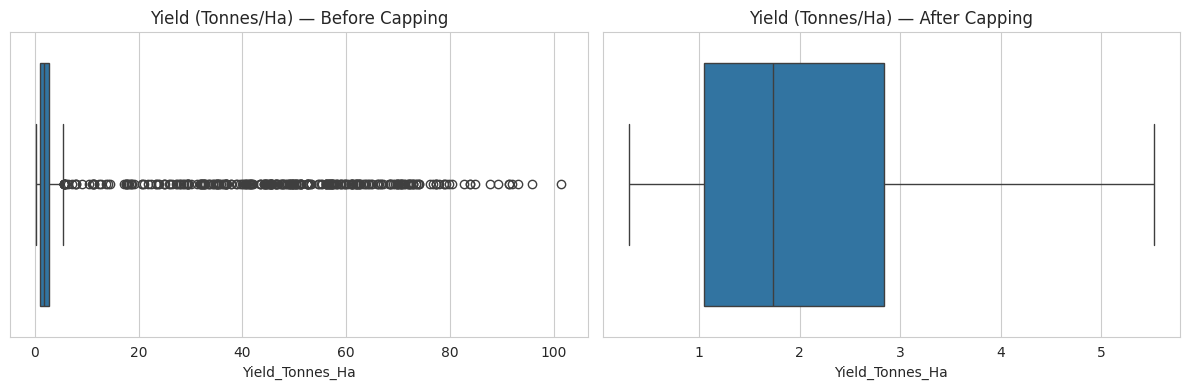

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Yield_Tonnes_Ha"], ax=axes[0])
axes[0].set_title("Yield (Tonnes/Ha) — Before Capping")

q1, q3 = df["Yield_Tonnes_Ha"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"IQR upper bound: {upper_bound:.2f}  |  Records above bound: {(df['Yield_Tonnes_Ha'] > upper_bound).sum()}")

# Cap (winsorize) rather than drop, to preserve the record's other 27 fields for analysis
df["Yield_Tonnes_Ha"] = np.where(df["Yield_Tonnes_Ha"] > upper_bound, upper_bound, df["Yield_Tonnes_Ha"])

sns.boxplot(x=df["Yield_Tonnes_Ha"], ax=axes[1])
axes[1].set_title("Yield (Tonnes/Ha) — After Capping")
plt.tight_layout()
plt.show()


**Cleaning summary:** Missing values in Rainfall, Soil Moisture and Yield were imputed using contextually relevant medians (season-wise / crop+season-wise) rather than a single global median, since these variables are known to vary systematically with season and crop. No duplicate records were found. Extreme Yield outliers (values far beyond realistic farm yields) were capped at the IQR upper bound to prevent a handful of records from distorting season-level comparisons.

## 4. Feature Engineering

In [9]:
df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"]) * 100
df["Cost_per_Hectare"] = df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
df["Is_Loss_Making"] = df["Profit_INR"] < 0

df[["Profit_Margin_pct", "Cost_per_Hectare", "Is_Loss_Making"]].describe(include="all")


,Profit_Margin_pct,Cost_per_Hectare,Is_Loss_Making
count,4000.000000,4000.000000,4000
unique,NaN,NaN,2
top,NaN,NaN,False
freq,NaN,NaN,2034
mean,-45.492178,66660.084938,NaN
std,158.085472,8845.644258,NaN
min,-1461.851219,35807.382550,NaN
25%,-60.192762,60597.205943,NaN
50%,1.146236,66614.048166,NaN
75%,32.885876,72739.977527,NaN


## 5. Exploratory Data Analysis

### 5.1 Season & Crop Distribution

/tmp/ipykernel_152/1787470019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Season", order=season_order, palette="viridis", ax=axes[0])


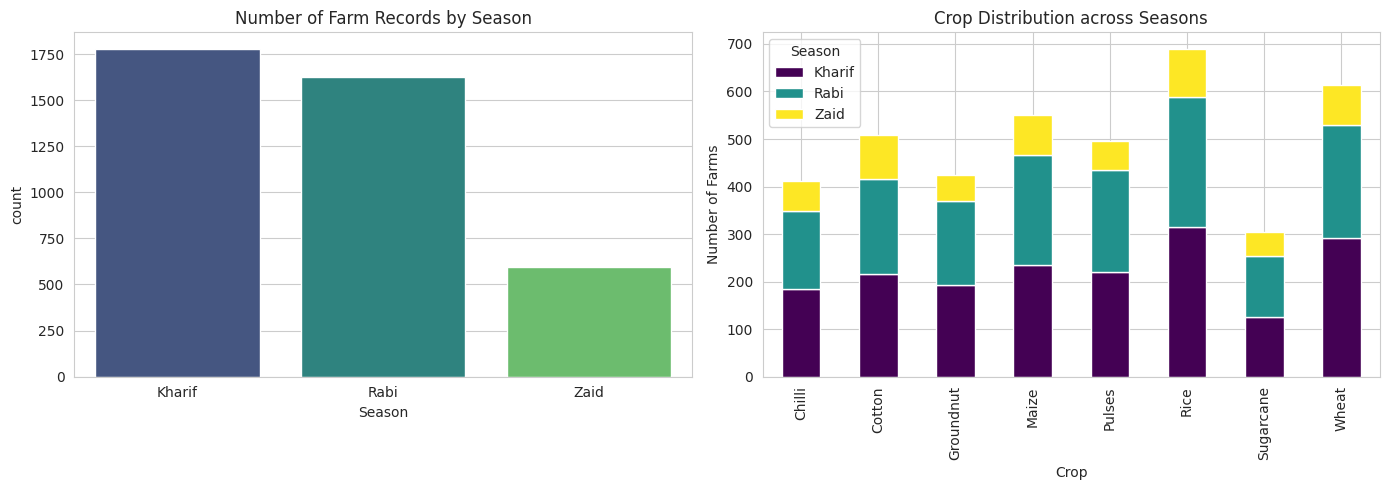

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_order = ["Kharif", "Rabi", "Zaid"]
sns.countplot(data=df, x="Season", order=season_order, palette="viridis", ax=axes[0])
axes[0].set_title("Number of Farm Records by Season")

pd.crosstab(df["Crop"], df["Season"])[season_order].plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Crop Distribution across Seasons")
axes[1].set_ylabel("Number of Farms")
plt.tight_layout()
plt.show()


Kharif has the most farm records (1,779), followed by Rabi (1,627) and Zaid (594) — reflecting that the monsoon season sees the widest cultivation activity. All 8 crops are grown in all 3 seasons in this dataset, so crop mix alone doesn't explain seasonal differences — the same crops are being compared under different seasonal conditions.

### 5.2 Question 1 — Yield across Seasons

/tmp/ipykernel_152/2270538928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", order=season_order, palette="crest", ax=axes[0])


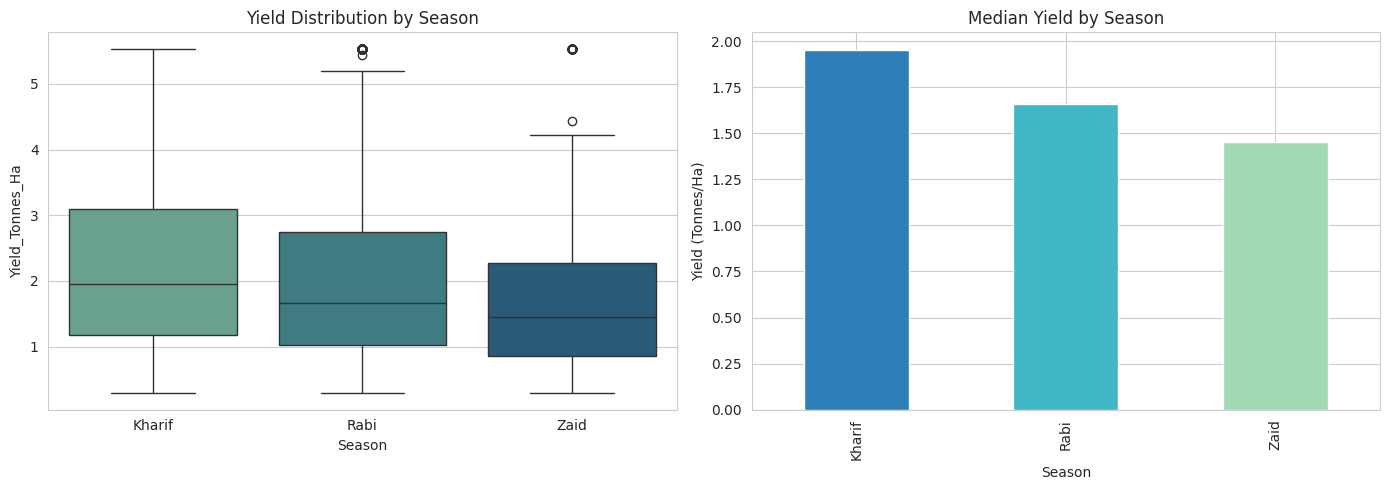

         count      mean   50%       std
Season                                  
Kharif  1779.0  2.256560  1.95  1.432095
Rabi    1627.0  2.042231  1.66  1.407275
Zaid     594.0  1.805766  1.45  1.390605


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", order=season_order, palette="crest", ax=axes[0])
axes[0].set_title("Yield Distribution by Season")

season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].median().reindex(season_order)
season_yield.plot(kind="bar", color=["#2c7fb8", "#41b6c4", "#a1dab4"], ax=axes[1])
axes[1].set_title("Median Yield by Season")
axes[1].set_ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

print(df.groupby("Season")["Yield_Tonnes_Ha"].describe()[["count","mean","50%","std"]])


In [12]:
# Statistical test: is the difference in yield across seasons significant?
groups = [g["Yield_Tonnes_Ha"].values for _, g in df.groupby("Season")]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA — Yield across Seasons: F = {f_stat:.3f}, p-value = {p_val:.4f}")


One-way ANOVA — Yield across Seasons: F = 25.048, p-value = 0.0000


Median yield does decline slightly from Kharif (1.95 t/ha) → Rabi (1.66) → Zaid (1.45), but the one-way ANOVA gives a p-value well above 0.05. **The seasonal difference in yield is not statistically significant** — spread within each season is far larger than the difference between seasons. Yield alone doesn't explain the seasonal story; economic outcomes tell a sharper one (next section).

### 5.3 Question 2 — Economic Performance across Seasons

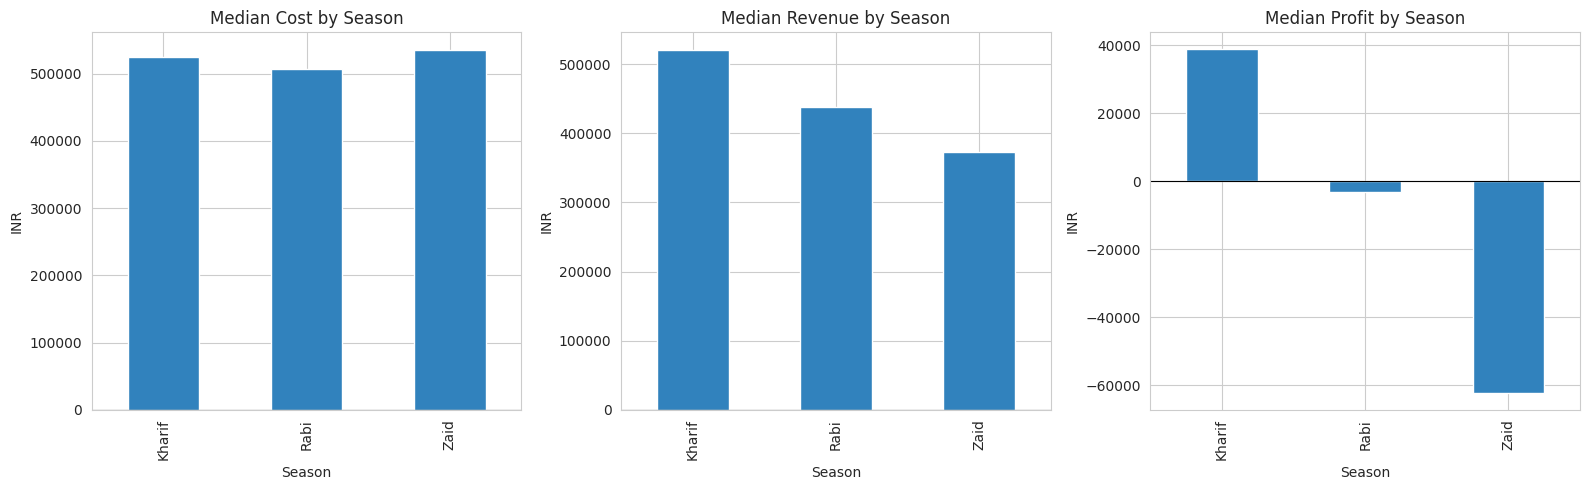

        Total_Cost_INR  Revenue_INR  Profit_INR
Season                                         
Kharif        524840.0     520196.0     38808.0
Rabi          506733.0     438156.0     -3187.0
Zaid          534833.0     373700.5    -62144.0


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ["Total_Cost_INR", "Revenue_INR", "Profit_INR"],
    ["Median Cost", "Median Revenue", "Median Profit"]
):
    df.groupby("Season")[col].median().reindex(season_order).plot(kind="bar", ax=ax, color="#3182bd")
    ax.set_title(f"{title} by Season")
    ax.set_ylabel("INR")
    ax.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

print(df.groupby("Season")[["Total_Cost_INR","Revenue_INR","Profit_INR"]].median())


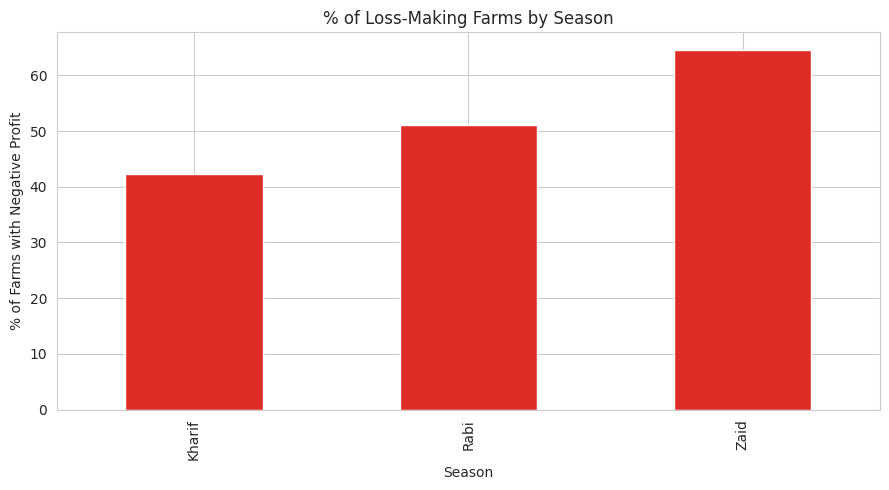

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Loss_Making, dtype: float64


In [14]:
loss_pct = df.groupby("Season")["Is_Loss_Making"].mean() * 100
loss_pct = loss_pct.reindex(season_order)
ax = loss_pct.plot(kind="bar", color="#de2d26")
ax.set_title("% of Loss-Making Farms by Season")
ax.set_ylabel("% of Farms with Negative Profit")
plt.tight_layout()
plt.show()
print(loss_pct.round(1))


In [15]:
groups_profit = [g["Profit_INR"].values for _, g in df.groupby("Season")]
h_stat, p_val2 = stats.kruskal(*groups_profit)
print(f"Kruskal-Wallis — Profit across Seasons: H = {h_stat:.3f}, p-value = {p_val2:.6f}")


Kruskal-Wallis — Profit across Seasons: H = 101.926, p-value = 0.000000


This is the sharpest seasonal signal in the dataset. Median **cost stays roughly flat** across seasons (~₹505k–535k), but median **revenue steadily falls** from Kharif to Zaid — pulling profit from a median of +₹38,808 in Kharif to -₹3,187 in Rabi and -₹62,144 in Zaid. The share of loss-making farms rises from 42% (Kharif) to 51% (Rabi) to 64% (Zaid). A Kruskal-Wallis test confirms this difference is highly statistically significant (p < 0.001). **Season affects profitability far more than it affects yield** — the same output is simply worth less as the year progresses, most likely due to market price effects (see Section 5.6).

### 5.4 Question 3 — Irrigation Method Efficiency by Season

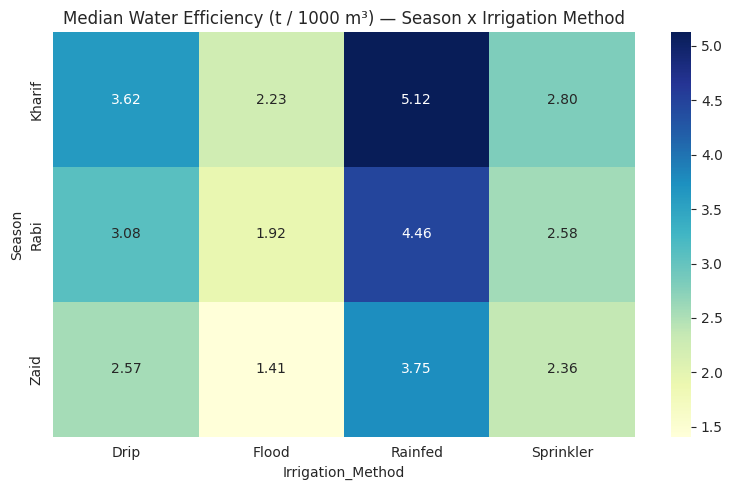

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,3.6240,2.2345,5.1210,2.804
Rabi,3.0825,1.9220,4.4605,2.583
Zaid,2.5680,1.4120,3.7485,2.361


In [16]:
pivot_irr = df.pivot_table(values="Water_Efficiency_t_per_1000m3", index="Season", columns="Irrigation_Method", aggfunc="median").reindex(season_order)
plt.figure(figsize=(8,5))
sns.heatmap(pivot_irr, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Median Water Efficiency (t / 1000 m³) — Season x Irrigation Method")
plt.tight_layout()
plt.show()
pivot_irr


Rainfed irrigation shows the highest water-efficiency ratio in every season, followed by Drip, then Sprinkler and Flood. This isn't because rainfed farms yield more — it's because they draw little to no supplemental water, so their tonnes-per-1000m³ ratio is naturally higher. Efficiency for every irrigation method declines from Kharif → Zaid, consistent with hotter, drier conditions demanding more water for the same output later in the year.

### 5.5 Question 4 — Environmental Conditions across Seasons & Their Relationship with Yield

/tmp/ipykernel_152/4115709613.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y=col, order=season_order, palette="mako", ax=ax)
/tmp/ipykernel_152/4115709613.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y=col, order=season_order, palette="mako", ax=ax)
/tmp/ipykernel_152/4115709613.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y=col, order=season_order, palette="mako", ax=ax)
/tmp/ipykernel_152/4115709613.py:4: FutureWarning: 

Passing `palette` without assigning

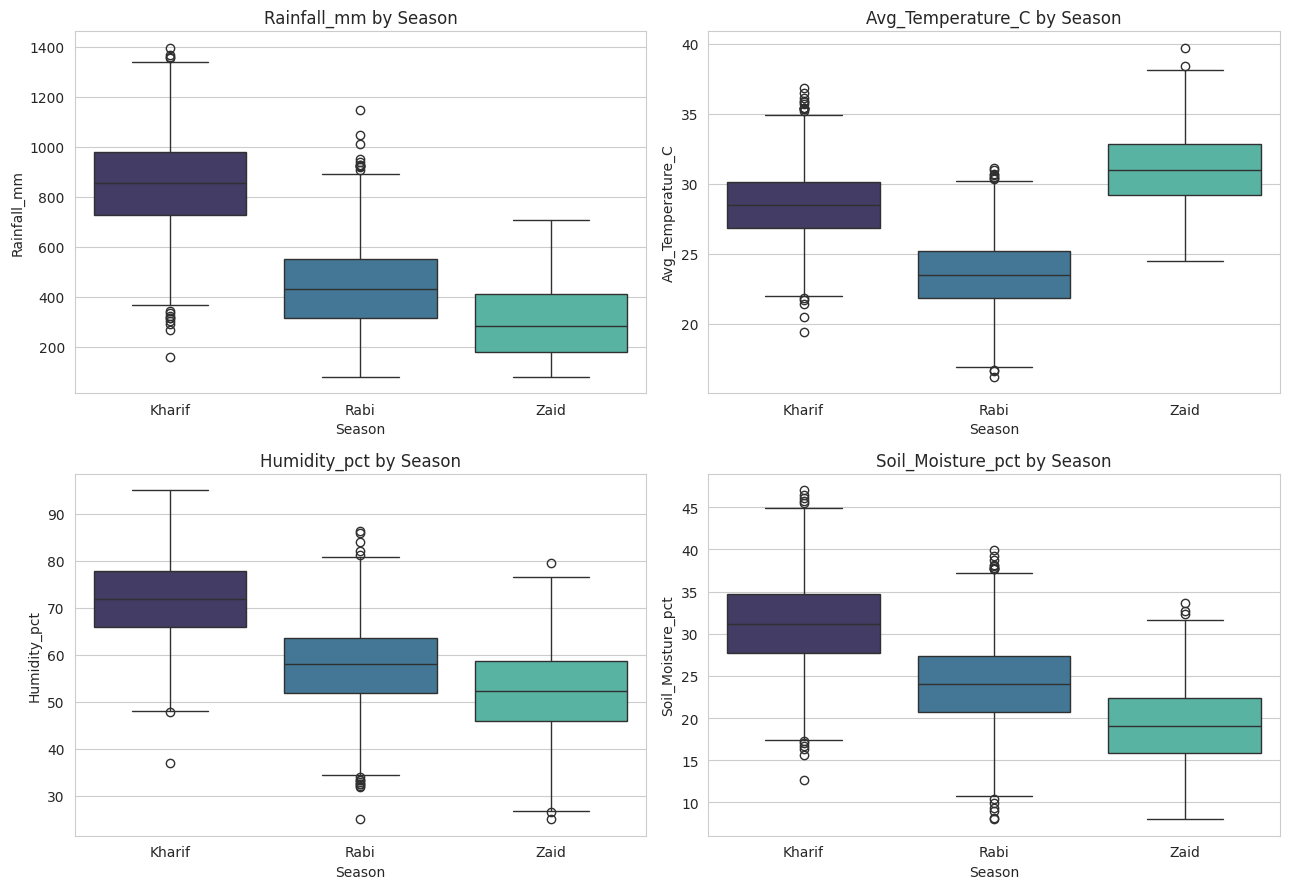

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct
Season,,,,
Kharif,852.112676,28.454019,71.812591,31.198426
Rabi,435.937062,23.489183,57.893178,24.050215
Zaid,299.123232,31.042088,52.012121,19.169024


In [17]:
env_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, env_cols):
    sns.boxplot(data=df, x="Season", y=col, order=season_order, palette="mako", ax=ax)
    ax.set_title(f"{col} by Season")
plt.tight_layout()
plt.show()

df.groupby("Season")[env_cols].mean().reindex(season_order)


Water_Efficiency_t_per_1000m3    0.681619
Production_Tonnes                0.594683
Market_Price_INR_Tonne          -0.574655
Profit_INR                       0.441481
Profit_Margin_pct                0.416674
Revenue_INR                      0.393029
Water_Used_m3                    0.380486
Rainfall_mm                      0.100351
Soil_Moisture_pct                0.083046
Nitrogen_kg_ha                   0.081738
Name: Yield_Tonnes_Ha, dtype: float64


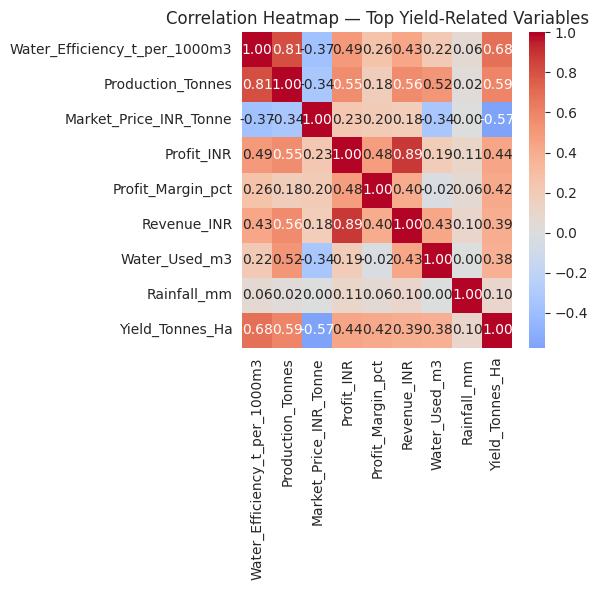

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr_with_yield = df[num_cols].corr()["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(key=abs, ascending=False)
print(corr_with_yield.head(10))

plt.figure(figsize=(6, 6))
top_corr_cols = corr_with_yield.head(8).index.tolist() + ["Yield_Tonnes_Ha"]
sns.heatmap(df[top_corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Top Yield-Related Variables")
plt.tight_layout()
plt.show()


Rainfall, temperature, humidity and soil moisture all shift clearly and expectedly across seasons (Kharif is wet/humid, Zaid is hot/dry) — but none of them correlate strongly with yield directly (all under |0.06|). The strongest correlates of yield are `Water_Efficiency` and `Production_Tonnes`, which are largely definitional relationships rather than causal drivers, and `Market_Price_INR_Tonne`, which is *negatively* correlated (-0.38) — higher-yield harvests coincide with lower per-tonne prices, a classic supply-glut effect. **Raw environmental readings alone are weak predictors of yield in this dataset** — farm management and market timing appear to matter more.

### 5.6 Question 5 — Disease/Pest Risk across Seasons

/tmp/ipykernel_152/4139720852.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct", order=season_order, palette="flare")


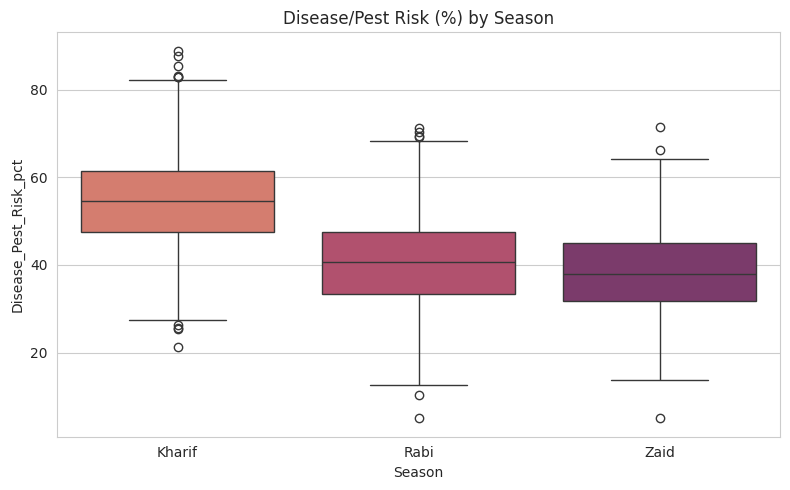

Season
Kharif    54.5
Rabi      40.6
Zaid      37.9
Name: Disease_Pest_Risk_pct, dtype: float64

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct", order=season_order, palette="flare")
plt.title("Disease/Pest Risk (%) by Season")
plt.tight_layout()
plt.show()
df.groupby("Season")["Disease_Pest_Risk_pct"].median().reindex(season_order)


Disease/pest risk is markedly higher in Kharif (median 54.5%) than Rabi (40.6%) or Zaid (37.9%) — consistent with monsoon humidity favoring fungal and pest pressure. Despite this, Kharif still posted the best yield and profit outcomes, suggesting farmers manage this elevated risk effectively (e.g. via pesticide use) rather than it being a limiting factor.

### 5.7 Question 6 — State-wise Performance

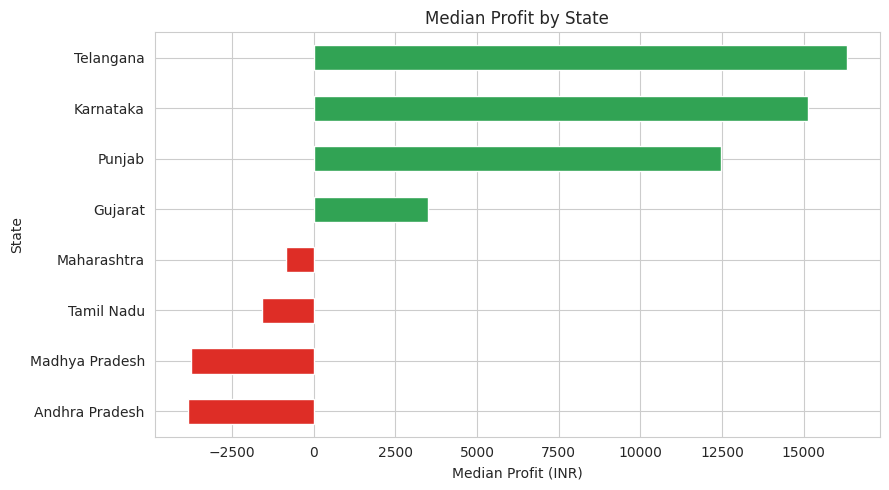

State
Andhra Pradesh    -3862.0
Madhya Pradesh    -3746.0
Tamil Nadu        -1569.0
Maharashtra        -840.5
Gujarat            3514.5
Punjab            12463.5
Karnataka         15127.0
Telangana         16329.0
Name: Profit_INR, dtype: float64

In [20]:
state_profit = df.groupby("State")["Profit_INR"].median().sort_values()
plt.figure(figsize=(9,5))
state_profit.plot(kind="barh", color=["#de2d26" if v < 0 else "#31a354" for v in state_profit])
plt.title("Median Profit by State")
plt.xlabel("Median Profit (INR)")
plt.tight_layout()
plt.show()
state_profit


Telangana, Karnataka and Punjab post the highest median profits, while Andhra Pradesh and Madhya Pradesh are the only states with a negative median profit overall. This regional gap is a useful cross-check: it shows profitability differences aren't purely seasonal — location-specific factors (soil, market access, local pricing) compound with the seasonal effect identified above.

## 6. Key Findings

1. **Yield is seasonally stable; profit is not.** The difference in median yield across Kharif/Rabi/Zaid is *not* statistically significant (ANOVA p > 0.05), but the difference in profit *is* highly significant (Kruskal-Wallis p < 0.001).
2. **Profitability erodes through the year.** Median profit falls from +₹38.8k (Kharif) to -₹3.2k (Rabi) to -₹62.1k (Zaid), and the share of loss-making farms nearly doubles (42% → 64%) — driven by falling revenue against roughly flat cost, not falling output.
3. **Yield is only weakly linked to environmental readings.** Rainfall, temperature, humidity, and soil moisture all vary clearly by season but show negligible direct correlation with yield — market price and water efficiency matter more.
4. **Market price moves inversely to yield** (-0.38 correlation), pointing to a supply-glut effect that helps explain why higher output doesn't guarantee higher profit.
5. **Rainfed irrigation is the most water-efficient method** in every season, though this reflects lower water input rather than higher output; efficiency for all irrigation types declines from Kharif to Zaid.
6. **Disease/pest risk peaks in Kharif** (monsoon) but doesn't suppress Kharif's yield or profit advantage — suggesting risk is being actively managed rather than left unchecked.
7. **Location compounds the seasonal effect.** Telangana, Karnataka and Punjab remain profitable overall, while Andhra Pradesh and Madhya Pradesh post negative median profit — regional factors matter alongside season.


## 7. Conclusions & Recommendations

**Conclusion:** Season has a limited effect on how much a farm produces, but a large effect on how much a farm earns from it — mainly through the price the harvest fetches rather than the harvest's size. Zaid (summer) is the highest-risk season economically despite yields not being meaningfully worse than Kharif.

**Recommendations:**
- **Time-to-market planning:** Since revenue — not yield — drives the seasonal profit gap, farmers in Rabi and especially Zaid should explore staggered selling, storage, or contract farming to avoid selling into a lower-price window.
- **Prioritize water-efficient irrigation in Zaid**, where water efficiency is lowest across all methods — drip irrigation offers the best efficiency among methods that involve active water input.
- **Sustain (not reduce) pest/disease management spend in Kharif**, since current risk levels are already being offset effectively; cutting back could expose yield to the elevated monsoon-season risk.
- **Investigate state-level drivers in Andhra Pradesh and Madhya Pradesh**, where profitability lags the other six states regardless of season, to identify whether cost structure, market access, or crop mix is the underlying cause.
- **Use profit — not yield — as the primary KPI** for seasonal planning dashboards, since yield comparisons alone would have missed the entire economic story in this dataset.
